<a href="https://colab.research.google.com/github/Bhavana-023/customer-segmentation-/blob/main/Customer_Segmentation_using_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Segmentation using Clustering (RFM Analysis)

## 1. Setup and Data Generation

Since no specific dataset was provided, I will generate a synthetic dataset that simulates retail transaction data. This dataset will include customer IDs, transaction dates, and purchase amounts, which are essential for RFM (Recency, Frequency, Monetary) analysis.

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Set a seed for reproducibility
np.random.seed(42)

# Number of customers and transactions
num_customers = 500
num_transactions = 5000

# Generate customer IDs
customer_ids = np.arange(1, num_customers + 1)

# Generate transaction data
transaction_data = []
current_date = datetime.now()

for _ in range(num_transactions):
    customer_id = np.random.choice(customer_ids)
    # Transactions mostly in the last year, with some older ones
    days_ago = np.random.randint(1, 365 * 2) # Up to 2 years old
    transaction_date = current_date - timedelta(days=days_ago)
    purchase_amount = np.random.uniform(5, 500) # Purchase amounts between 5 and 500
    transaction_data.append([customer_id, transaction_date, purchase_amount])

df = pd.DataFrame(transaction_data, columns=['CustomerID', 'TransactionDate', 'PurchaseAmount'])

# Display the first few rows and information about the generated data
print("Generated Data Head:")
display(df.head())

print("\nData Info:")
df.info()

Generated Data Head:


,CustomerID,TransactionDate,PurchaseAmount
0,103,2025-06-02 04:40:45.767013,475.603582
1,107,2026-06-01 04:40:45.767013,301.335950
2,103,2026-04-12 04:40:45.767013,82.217288
3,331,2025-05-10 04:40:45.767013,433.757192
4,100,2024-10-17 04:40:45.767013,327.189794



Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   CustomerID       5000 non-null   int64         
 1   TransactionDate  5000 non-null   datetime64[ns]
 2   PurchaseAmount   5000 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 117.3 KB


## 2. RFM Feature Engineering

Now, we will calculate the Recency, Frequency, and Monetary values for each customer. This is the core of RFM analysis:
- **Recency (R):** How recently did the customer make a purchase? Calculated as the number of days since the last transaction.
- **Frequency (F):** How often does the customer purchase? Calculated as the total number of transactions.
- **Monetary (M):** How much does the customer spend? Calculated as the total sum of all purchase amounts.

In [2]:
# Calculate a snapshot date for RFM analysis (e.g., the day after the last transaction in the dataset)
snapshot_date = df['TransactionDate'].max() + timedelta(days=1)

# Group by CustomerID and calculate RFM values
rfm_df = df.groupby('CustomerID').agg(
    Recency=('TransactionDate', lambda date: (snapshot_date - date.max()).days), # Days since last transaction
    Frequency=('TransactionDate', 'count'),                                  # Total number of transactions
    Monetary=('PurchaseAmount', 'sum')                                     # Total purchase amount
).reset_index()

# Display the first few rows of the RFM DataFrame
print("RFM DataFrame Head:")
display(rfm_df.head())

print("\nRFM DataFrame Info:")
rfm_df.info()

RFM DataFrame Head:


,CustomerID,Recency,Frequency,Monetary
0,1,119,9,2356.763699
1,2,10,10,2559.354432
2,3,16,11,2573.142105
3,4,138,11,3000.000498
4,5,119,5,1350.400922



RFM DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  500 non-null    int64  
 1   Recency     500 non-null    int64  
 2   Frequency   500 non-null    int64  
 3   Monetary    500 non-null    float64
dtypes: float64(1), int64(3)
memory usage: 15.8 KB


## 3. Data Preprocessing for Clustering

Before applying clustering algorithms, it is crucial to preprocess the RFM data. The steps include:
1.  **Handling Skewness:** RFM values often follow a skewed distribution, which can negatively impact the performance of distance-based clustering algorithms like K-Means. We will apply a log transformation (e.g., `np.log1p`) to normalize the distribution.
2.  **Feature Scaling:** Clustering algorithms are sensitive to the scale of features. We will use `StandardScaler` to transform the data so that it has a mean of 0 and a standard deviation of 1, ensuring all features contribute equally to the distance calculations.

In [3]:
from sklearn.preprocessing import StandardScaler

# Apply log transformation to handle skewness (add 1 to avoid log(0))
rfm_log = rfm_df[['Recency', 'Frequency', 'Monetary']].apply(np.log1p)

# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform the log-transformed RFM features
rfm_scaled = scaler.fit_transform(rfm_log)

# Convert the scaled data back to a DataFrame for better readability
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency_Scaled', 'Frequency_Scaled', 'Monetary_Scaled'])

# Display the first few rows of the scaled RFM DataFrame
print("Scaled RFM DataFrame Head:")
display(rfm_scaled_df.head())

print("\nScaled RFM DataFrame Info:")
rfm_scaled_df.info()

Scaled RFM DataFrame Head:


,Recency_Scaled,Frequency_Scaled,Monetary_Scaled
0,0.879933,-0.161041,0.038655
1,-1.237767,0.146638,0.245690
2,-0.851981,0.427526,0.259179
3,1.010191,0.427526,0.644529
4,0.879933,-1.810076,-1.359219



Scaled RFM DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Recency_Scaled    500 non-null    float64
 1   Frequency_Scaled  500 non-null    float64
 2   Monetary_Scaled   500 non-null    float64
dtypes: float64(3)
memory usage: 11.8 KB


## 4. Determine Optimal Number of Clusters (K-Means)

To find the optimal number of clusters (k) for K-Means, we will use the **Elbow Method**. This method involves plotting the sum of squared distances (inertia) from each point to its assigned center (cluster), against the number of clusters. The 'elbow' point in the plot, where the rate of decrease in inertia sharply changes, is considered an indicator of the optimal number of clusters.

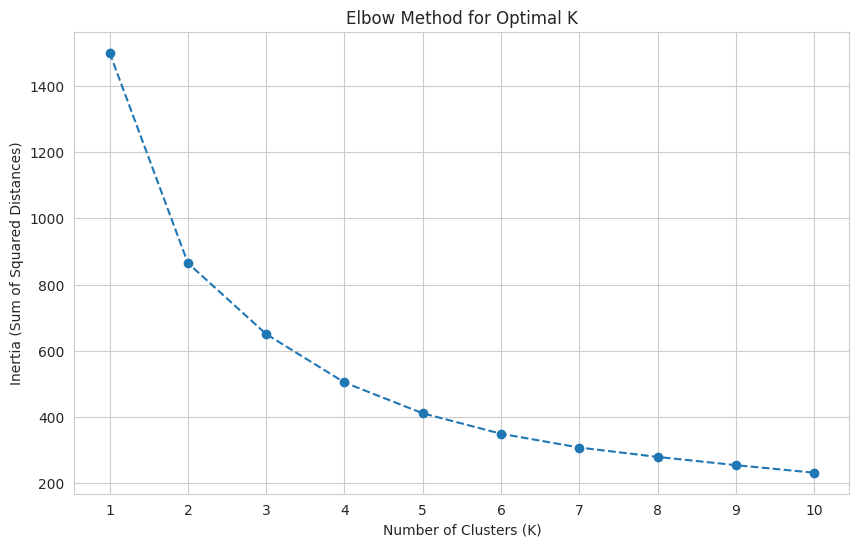

In [4]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Calculate inertia for a range of cluster numbers
inertia = []
max_clusters = 10

for i in range(1, max_clusters + 1):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10) # n_init for robust centroid initialization
    kmeans.fit(rfm_scaled_df)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, max_clusters + 1), inertia, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.xticks(range(1, max_clusters + 1))
plt.grid(True)
plt.show()

## 5. K-Means Clustering

Based on the Elbow Method, we will proceed with **4 clusters** for our K-Means model. After clustering, we will assign each customer to their respective cluster and then merge these cluster labels back into our original RFM DataFrame for further analysis and interpretation.

In [5]:
n_clusters = 4 # Based on the Elbow Method

kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
kmeans.fit(rfm_scaled_df)

# Add the cluster labels to the RFM DataFrame
rfm_df['Cluster'] = kmeans.labels_

# Display the first few rows with the new cluster assignments
print("RFM DataFrame with Cluster Assignments:")
display(rfm_df.head())

print("\nCluster Distribution:")
display(rfm_df['Cluster'].value_counts().sort_index())

RFM DataFrame with Cluster Assignments:


,CustomerID,Recency,Frequency,Monetary,Cluster
0,1,119,9,2356.763699,0
1,2,10,10,2559.354432,1
2,3,16,11,2573.142105,1
3,4,138,11,3000.000498,0
4,5,119,5,1350.400922,2



Cluster Distribution:


,count
Cluster,
0,182
1,125
2,79
3,114


## 6. Cluster Analysis and Interpretation

After assigning customers to clusters, the next step is to analyze the characteristics of each cluster. We will do this by examining the average Recency, Frequency, and Monetary values for each segment. This will help us define distinct customer personas and formulate targeted marketing strategies.

Cluster Summary (Mean RFM Values):


,Cluster,Recency,Frequency,Monetary
0,0,115.010989,9.060440,2236.712606
1,1,12.864000,10.336000,2549.917620
2,2,99.987342,5.594937,1305.342002
3,3,55.298246,14.184211,3674.566957


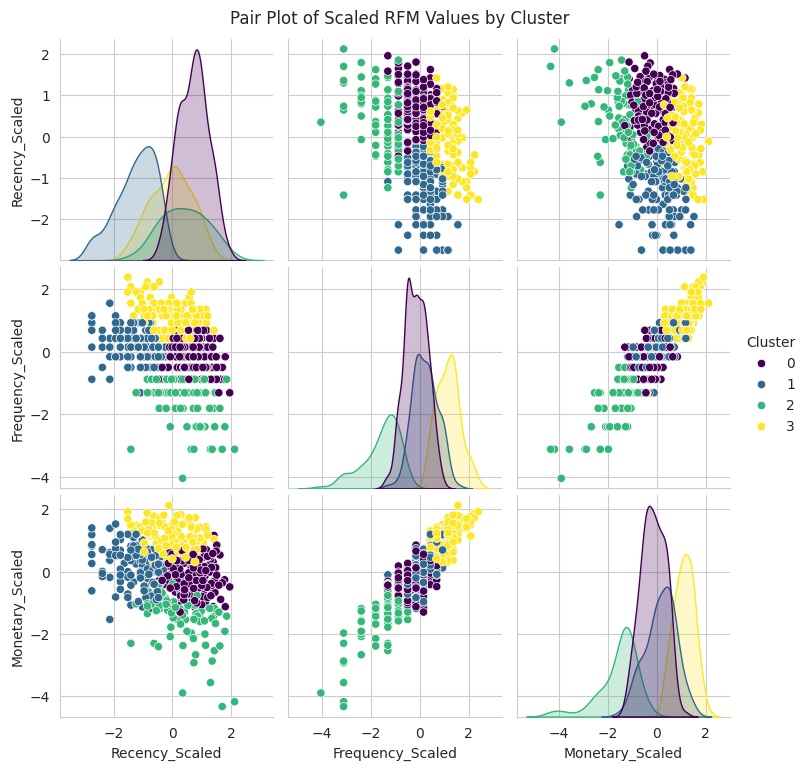

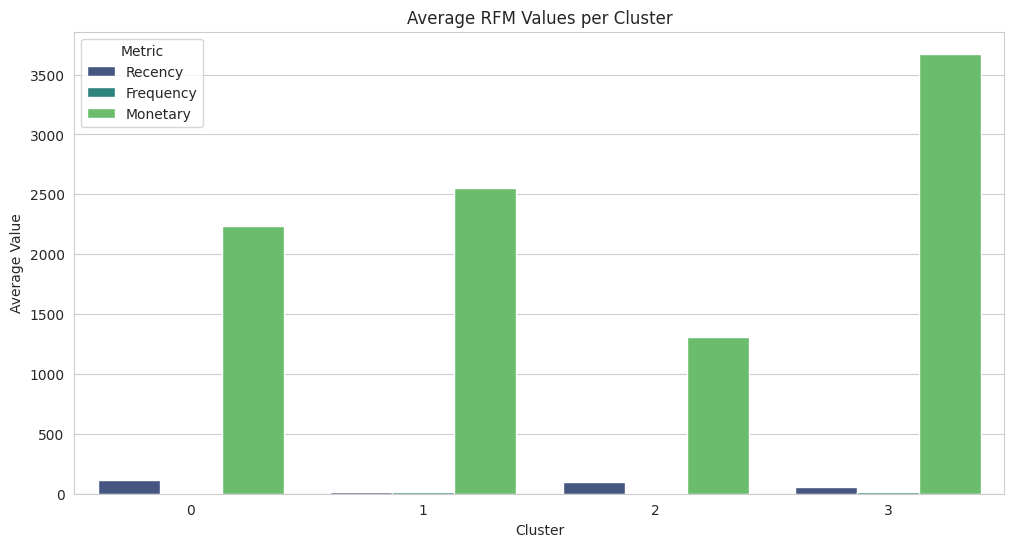

In [6]:
# Calculate the mean RFM values for each cluster
cluster_summary = rfm_df.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().reset_index()

print("Cluster Summary (Mean RFM Values):")
display(cluster_summary)

# Visualize the clusters
# Let's use pair plots to see the distribution and relationships between RFM values per cluster
# and then a bar plot for mean RFM values for better comparison.

# Prepare data for plotting (merge scaled RFM with original RFM and cluster labels)
rfm_combined = pd.concat([rfm_df[['CustomerID', 'Cluster']], rfm_log, rfm_scaled_df], axis=1)

# Pair plot of scaled RFM values by cluster
# This helps visualize how distinct the clusters are in the transformed space
sns.pairplot(rfm_combined, vars=['Recency_Scaled', 'Frequency_Scaled', 'Monetary_Scaled'], hue='Cluster', palette='viridis')
plt.suptitle('Pair Plot of Scaled RFM Values by Cluster', y=1.02) # Adjust title position
plt.show()

# Melt the cluster_summary for easier bar plotting
cluster_summary_melted = pd.melt(cluster_summary, id_vars=['Cluster'], var_name='Metric', value_name='Average Value')

plt.figure(figsize=(12, 6))
sns.barplot(x='Cluster', y='Average Value', hue='Metric', data=cluster_summary_melted, palette='viridis')
plt.title('Average RFM Values per Cluster')
plt.ylabel('Average Value')
plt.xlabel('Cluster')
plt.show()

## 7. Defining Customer Personas and Marketing Strategies

Based on the average RFM values for each cluster, we can define distinct customer personas and propose targeted marketing strategies.

Let's analyze the `cluster_summary`:
-   **Cluster 0:**
    -   Recency: Moderate (around 115 days)
    -   Frequency: Moderate (around 9 transactions)
    -   Monetary: Moderate (around $2236)
    -   **Persona:** These are **Regular Customers**. They purchase somewhat recently and frequently, spending a good amount. They are a stable segment but might be at risk of becoming less active. They are the largest segment.
    -   **Marketing Strategy:** Engage them with personalized recommendations, loyalty programs, and exclusive early access to new products. Provide incentives for continued purchases to prevent churn.

-   **Cluster 1:**
    -   Recency: Very Low (around 13 days - very recent)
    -   Frequency: Moderate (around 10 transactions)
    -   Monetary: Moderate (around $2549)
    -   **Persona:** These are **New/Active Engaged Customers**. They have purchased very recently, and their frequency and monetary values are good. They are currently highly engaged.
    -   **Marketing Strategy:** Nurture their engagement with excellent customer service, post-purchase follow-ups, and surveys to understand their needs. Encourage repeat purchases through personalized offers and highlight benefits of ongoing relationship.

-   **Cluster 2:**
    -   Recency: Moderate (around 100 days)
    -   Frequency: Low (around 5 transactions)
    -   Monetary: Low (around $1305)
    -   **Persona:** These are **At-Risk/Slipping Customers**. They haven't purchased recently, have lower frequency, and spend less. They might be losing interest.
    -   **Marketing Strategy:** Re-engagement campaigns are crucial. Offer special discounts, personalized product suggestions based on past purchases, or limited-time promotions to bring them back. Understand reasons for their reduced activity.

-   **Cluster 3:**
    -   Recency: Low (around 55 days)
    -   Frequency: High (around 14 transactions)
    -   Monetary: High (around $3674)
    -   **Persona:** These are **Loyal High-Value Customers**. They purchase relatively recently, very frequently, and spend the most. They are your most valuable customers.
    -   **Marketing Strategy:** Reward their loyalty with VIP programs, exclusive access to premium products/services, personalized thank-you notes, and dedicated support. Encourage referrals and collect testimonials.

## Summary

In this notebook, we performed customer segmentation using RFM analysis and K-Means clustering:

1.  **Data Generation:** Started by creating a synthetic retail transaction dataset as a foundation for analysis.
2.  **RFM Feature Engineering:** Calculated Recency, Frequency, and Monetary values for each customer.
3.  **Data Preprocessing:** Applied log transformation to handle skewness and scaled the RFM features using `StandardScaler`.
4.  **Optimal Clusters:** Used the Elbow Method to determine an optimal number of 4 clusters for K-Means.
5.  **K-Means Clustering:** Applied K-Means with 4 clusters and assigned each customer to a segment.
6.  **Cluster Analysis:** Analyzed the mean RFM values for each cluster to understand their characteristics.
7.  **Customer Personas & Strategy:** Defined 4 actionable customer personas: **Regular Customers**, **New/Active Engaged Customers**, **At-Risk/Slipping Customers**, and **Loyal High-Value Customers**, and suggested targeted marketing strategies for each. This provides a clear roadmap for personalized customer engagement and retention efforts.